<a href="https://colab.research.google.com/github/RoeeLanger/BGU_Web_Course/blob/main/WaterParkSimulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# קבוצה 28
<div dir="rtl">
מגישים: ים טבו/ 324026624, תום יוסף  בלונדר/ 319027066, רועי לנגר/ 322970179

## Imports

In [ ]:
import random
import math
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import kstest
from google.colab import files
import heapq

## Sampling Algorithms

### שעת עזיבה משפחה

$$f(x)=\begin{cases}
    \frac{2}{9}(x-16) & \text{if } 16 \le x < 19\\
    0 & \text{else}
\end{cases}$$

חישוב צפיפות מצטברת


$$\displaylines{F(x)=\begin{cases}
    0 & \text{if } x \le 16 \\
    \int_{16}^x\frac{2}{9}(x-16)dx & \text{if } x > 0\\
    1 & \text{if }x\geq 19
\end{cases} \\ \int_{16}^x\frac{2}{9}(x-16)dx = \frac{2}{9} \int_{16}^x(x-16)dx =\frac{2}{9}*\frac{(x-16^2)}{2}\vert^x_{16}=\\\frac{(x-16)^2}{9}\\F(x)=\begin{cases}
    0 & \text{if } x \le 16 \\
    \frac{(x-16)^2}{9} & \text{if } 16\leq x <19\\
    1 & \text{if }x\geq 19
\end{cases}}$$

בניית אלגוריתם דגימה - טרנספורם הופכי

$$\displaylines{u\sim unif(0,1)\\ F(x) = u\rightarrow \frac{(x-16)^2}{9} = u\\x-16=3\sqrt{u}\rightarrow x(u) = 3\sqrt{u}+16}$$
Algorithm:
1. Sample $u_1\sim unif(0,1)$
2. return $x(u_1)=3\sqrt{u_1}+16$

### משך המתקן בריכת קטנטנים

$$f(x)=\begin{cases}
    \frac{16}{3}(x-1) & \text{if }  1 \leq x < 1.25 \\
    \frac{4}{3} & \text{if } 1.25 \le  x < 1.75\\
    \frac{16}{3}(2-x) & \text{if } 1.75\le x \le 2
\end{cases}$$

חישוב הסתברות לכל תחום


$$
p_1=\int_{1}^{1.25}\frac{16}{3}(x-1)\,dx=\frac16,\qquad
p_2=\int_{1.25}^{1.75}\frac{4}{3}\,dx=\frac23,\qquad
p_3=\int_{1.75}^{2}\frac{16}{3}(2-x)\,dx=\frac16.
$$


####נחשב פונקציות צפיפות לכל רכיב

$$f_1(x)=f(x\mid 1\le x<1.25)=\frac{f(x)}{p_1}=
\begin{cases}
32(x-1), & 1\le x<1.25,\\
0, & \text{otherwise},
\end{cases}$$



$$f_2(x)=f(x\mid 1.25\le x<1.75)=\frac{f(x)}{p_2}
=
\begin{cases}
2, & 1.25\le x<1.75,\\
0, & \text{otherwise},
\end{cases}$$



$$f_3(x)=f(x\mid 1.75\le x\le 2)=\frac{f(x)}{p_3}
=
\begin{cases}
32(2-x), & 1.75\le x\le 2,\\
0, & \text{otherwise}.
\end{cases}$$


נחשב צפיפות מצטברת

$$\displaylines{F_1(x)=\int_{1}^{x}32(t-1)\,dt=16(x-1)^2
\quad\Rightarrow\quad
X_1=F_1^{-1}(V)=1+\frac{\sqrt{V}}{4}\\F_2(x)=\int_{1.25}^{x}2\,dt=2(x-1.25)
\quad\Rightarrow\quad
X_2=F_2^{-1}(V)=1.25+\frac{V}{2}.\\F_3(x)=\int_{1.75}^{x}32(2-t)\,dt
=1-16(2-x)^2
\quad\Rightarrow\quad
X_3=F_3^{-1}(V)=2-\frac{\sqrt{1-V}}{4}.}$$

אלגוריתם דגימה

$$ \begin{aligned}
&U\sim \mathrm{Unif}(0,1).\\
&\text{If }U<\frac16,\ \text{draw }V\sim \mathrm{Unif}(0,1)\ \text{and set }X=1+\frac{\sqrt{V}}{4}.\\
&\text{Else if }U<\frac56,\ \text{draw }V\sim \mathrm{Unif}(0,1)\ \text{and set }X=1.25+\frac{V}{2}.\\
&\text{Else, draw }V\sim \mathrm{Unif}(0,1)\ \text{and set }X=2-\frac{\sqrt{1-V}}{4}.\\
&\text{Return }60X\ \text{(minutes)}.
\end{aligned}$$

### בדיקות סטטיסטיות עבור מתקנים אבובים גדולים וקטנים:


Saving samples for course project (1).xlsx to samples for course project (1).xlsx
Sheet names found: ['מגלשת אבובים גדולה', 'מגלשת אבובים קטנה ']
Ride 3 sample size: 100
Ride 4 sample size: 100


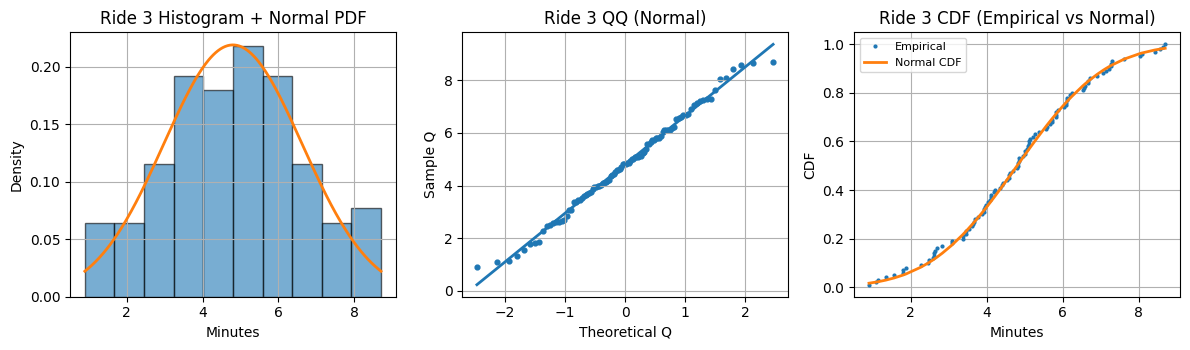


===== Ride 3 – Normal fit (KS Test) =====
mu: 4.800664419398341
sigma: 1.8231008561248123
KS statistic (D): 0.03695276253212795
p-value: 0.9984508973564586
Critical value (alpha=0.05): 0.136
Decision: Fail to reject H0 (Normal is a reasonable model).


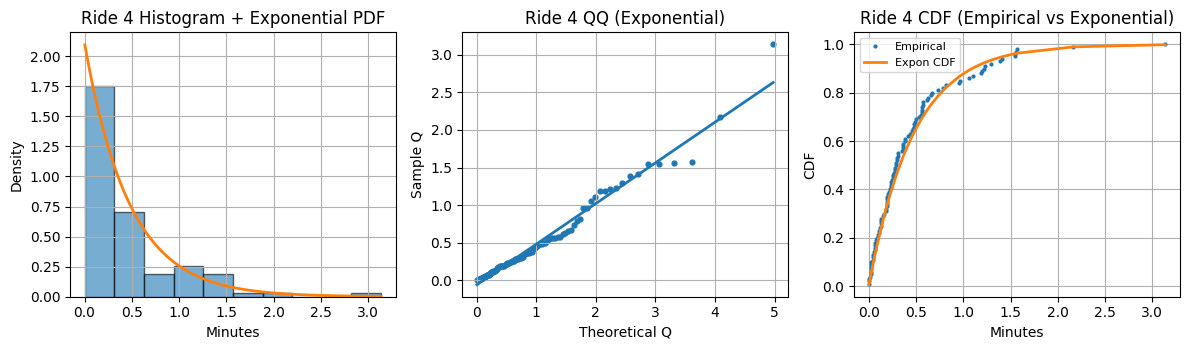


===== Ride 4 – Exponential fit (KS Test) =====
lambda: 2.107060217839333
KS statistic (D): 0.06845535254374335
p-value: 0.7105730836416237
Critical value (alpha=0.05): 0.136
Decision: Fail to reject H0 (Exponential is a reasonable model).


In [ ]:


# -----------------------------
# Upload Excel (Colab)
# -----------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
file_bytes = uploaded[file_name]

xls = pd.ExcelFile(io.BytesIO(file_bytes))
print("Sheet names found:", xls.sheet_names)

# -----------------------------
# Sheet names (KEEP EXACT)
# -----------------------------
ride3_sheet = "מגלשת אבובים גדולה"
ride4_sheet = "מגלשת אבובים קטנה "

# Load data
ride3_df = pd.read_excel(io.BytesIO(file_bytes), sheet_name=ride3_sheet)
ride4_df = pd.read_excel(io.BytesIO(file_bytes), sheet_name=ride4_sheet)

# Assuming column is called "time_minutes"
ride3_times = ride3_df["time_minutes"].dropna()
ride4_times = ride4_df["time_minutes"].dropna()

print("Ride 3 sample size:", len(ride3_times))
print("Ride 4 sample size:", len(ride4_times))

alpha = 0.05

# -----------------------------
# Plot helpers (smaller plots for 1-row layout)
# -----------------------------
def plot_hist(ax, data, title, dist_name, params, bins=10):
    data = np.asarray(data)
    x_vals = np.linspace(data.min(), data.max(), 250)
    ax.hist(data, bins=bins, density=True, alpha=0.6, edgecolor='black')

    if dist_name == "norm":
        mu_, sigma_ = params
        ax.plot(x_vals, stats.norm.pdf(x_vals, loc=mu_, scale=sigma_), lw=2)
        ax.set_title(title)
    elif dist_name == "expon":
        lam_ = params[0]
        ax.plot(x_vals, stats.expon.pdf(x_vals, loc=0, scale=1/lam_), lw=2)
        ax.set_title(title)

    ax.set_xlabel("Minutes")
    ax.set_ylabel("Density")
    ax.grid(True)

def plot_qq(ax, data, title, dist="norm"):
    (osm, osr), (slope, intercept, r) = stats.probplot(np.asarray(data), dist=dist)
    ax.scatter(osm, osr, s=12)
    xline = np.array([osm.min(), osm.max()])
    ax.plot(xline, slope * xline + intercept, lw=2)
    ax.set_title(title)
    ax.set_xlabel("Theoretical Q")
    ax.set_ylabel("Sample Q")
    ax.grid(True)

def plot_cdf(ax, data, title, dist_name, params):
    data = np.asarray(data)
    xs = np.sort(data)
    n = len(xs)
    ecdf = np.arange(1, n + 1) / n
    ax.plot(xs, ecdf, marker='.', linestyle='none', markersize=4, label='Empirical')

    if dist_name == "norm":
        mu_, sigma_ = params
        ax.plot(xs, stats.norm.cdf(xs, loc=mu_, scale=sigma_), lw=2, label='Normal CDF')
    elif dist_name == "expon":
        lam_ = params[0]
        ax.plot(xs, stats.expon.cdf(xs, loc=0, scale=1/lam_), lw=2, label='Expon CDF')

    ax.set_title(title)
    ax.set_xlabel("Minutes")
    ax.set_ylabel("CDF")
    ax.legend(fontsize=8)
    ax.grid(True)

# -----------------------------
# Ride 3 block (Histogram + QQ + CDF on one row, then KS output)
# -----------------------------
ride3 = np.array(ride3_times)
mu, sigma = np.mean(ride3), np.std(ride3, ddof=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
plot_hist(axes[0], ride3, "Ride 3 Histogram + Normal PDF", "norm", (mu, sigma), bins=10)
plot_qq(axes[1], ride3, "Ride 3 QQ (Normal)", dist="norm")
plot_cdf(axes[2], ride3, "Ride 3 CDF (Empirical vs Normal)", "norm", (mu, sigma))
plt.tight_layout()
plt.show()

D, p = kstest(ride3, "norm", args=(mu, sigma))
n3 = len(ride3)
D_critical_ride3 = 1.36 / np.sqrt(n3)

print("\n===== Ride 3 – Normal fit (KS Test) =====")
print("mu:", mu)
print("sigma:", sigma)
print("KS statistic (D):", D)
print("p-value:", p)
print("Critical value (alpha=0.05):", D_critical_ride3)
if D <= D_critical_ride3 and p > alpha:
    print("Decision: Fail to reject H0 (Normal is a reasonable model).")
else:
    print("Decision: Reject H0 (Normal is not a good fit).")

# -----------------------------
# Ride 4 block (Histogram + QQ + CDF on one row, then KS output)
# -----------------------------
ride4 = np.array(ride4_times)
lambda_ride4 = 1 / np.mean(ride4)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
plot_hist(axes[0], ride4, "Ride 4 Histogram + Exponential PDF", "expon", (lambda_ride4,), bins=10)
plot_qq(axes[1], ride4, "Ride 4 QQ (Exponential)", dist="expon")
plot_cdf(axes[2], ride4, "Ride 4 CDF (Empirical vs Exponential)", "expon", (lambda_ride4,))
plt.tight_layout()
plt.show()

D_ride4, p_ride4 = kstest(ride4, "expon", args=(0, 1 / lambda_ride4))
n4 = len(ride4)
D_critical_ride4 = 1.36 / np.sqrt(n4)

print("\n===== Ride 4 – Exponential fit (KS Test) =====")
print("lambda:", lambda_ride4)
print("KS statistic (D):", D_ride4)
print("p-value:", p_ride4)
print("Critical value (alpha=0.05):", D_critical_ride4)
if D_ride4 <= D_critical_ride4 and p_ride4 > alpha:
    print("Decision: Fail to reject H0 (Exponential is a reasonable model).")
else:
    print("Decision: Reject H0 (Exponential is not a good fit).")


## Static sampeling class

In [ ]:
class SimulationUtils:

    @staticmethod
    def sample_num_children():
        """
        Samples the number of children in a family.
        Discrete Uniform {1, 2, 3, 4, 5} implemented using U(0,1).
        """
        u = random.random()  # U(0,1)
        return 1 + int(5 * u)  # (b - a + 1) = (5 - 1 + 1) = 5

    @staticmethod
    def sample_child_age():
        """
        Samples a child's age from a continuous Uniform(2, 18) distribution.
        """
        u = random.random()  # U(0,1)
        return 2 + (18 - 2) * u

    @staticmethod
    def sample_interarrival_family():
        """
        Samples the interarrival time of families.
        Arrival rate = 40 families per hour → mean interarrival = 1.5 minutes.
        Returns the interarrival time in MINUTES.
        """
        u = random.random()  # U(0,1)
        return -1.5 * math.log(1 - u)

    @staticmethod
    def sample_family_departure_time_minutes():
        """
        Sample family departure time in MINUTES since midnight.
        Park closing for families: between 16:00 (960) and 19:00 (1140).
        """
        u = random.random()
        x_hours = 16 + 3 * math.sqrt(u)  # X in hours
        t_minutes = x_hours * 60         # minutes since midnight
        return t_minutes

    @staticmethod
    def sample_teens_group_size():
        """
        Samples the number of members in a teen group.
        """
        u = random.random()  # U(0,1)
        if u < 0.2:
            return 2
        elif u < 0.4:   # 0.2 + 0.2
            return 3
        elif u < 0.65:  # 0.4 + 0.25
            return 4
        elif u < 0.90:  # 0.65 + 0.25
            return 5
        else:
            return 6

    @staticmethod
    def sample_interarrival_teens():
        """
        Samples the interarrival time (in MINUTES) for teen groups.
        500 arrivals in a 6-hour window → mean = 6/500 hours ≈ 0.72 minutes.
        """
        u = random.random()
        return -0.72 * math.log(1 - u)

    @staticmethod
    def sample_interarrival_single_reg():
        """
        Samples the interarrival time (in MINUTES) for single visitors.
        Given:
            10 visitors arrive every 15 minutes.
            ⇒ 40 per hour, mean interarrival time = 1/40 hours = 1.5 minutes.
        """
        u = random.random()  # U(0,1)
        return -1.5 * math.log(1 - u)


    @staticmethod
    def sample_interarrival_single_alt():
        """
        Samples the interarrival time (in MINUTES) for single visitors.
        Given:
            20 visitors arrive every 15 minutes.
            ⇒ 40 per hour, mean interarrival time = 1/40 hours = 1.5 minutes.
        """
        u = random.random()  # U(0,1)
        return -0.75 * math.log(1 - u)

    @staticmethod
    def sample_river_tube_duration():
        """
        Samples the activity duration (in minutes) for the river tube ride.
        Distribution: Uniform(20, 30) minutes.
        """
        u = random.random()  # U(0,1)
        return 20 + (30 - 20) * u

    @staticmethod
    def sample_big_tube_duration():
        """
        Samples the ride duration (in minutes) for the big tube slide.
        Distribution: Normal(mu=4.800664419398341, sigma=1.8231008561248123)
        using the Box–Muller transform.
        """
        u1 = random.random()
        u2 = random.random()

        # Box-Muller: Z ~ N(0,1)
        z = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)

        # Scale and shift: X = mu + sigma * Z
        mu = 4.800664419398341
        sigma = 1.8231008561248123
        return mu + sigma * z

    @staticmethod
    def sample_small_tube_duration():
        """
        Samples the ride duration (in minutes) for the small tube slide.
        Distribution: Exponential with lambda = 2.107060217839333.
        """
        u = random.random()  # U(0,1)
        lam = 2.107060217839333
        return -math.log(1 - u) / lam

    @staticmethod
    def sample_wave_pool_duration():
      def sample_from_f(x): # replicates the density function in instructions
        if 0 <= x <=30:
          return x/2700
        elif 30<x<= 50:
          return (60 - x)/2700 + 1/30

        elif 50 <x<=60:
          return (60-x)/2700
        else:
          return 0
      def sample_g(): #bounding function is unif(0,60), same support, easy to sample.
        u = random.random()*60
        return u

      def get_M(x):# decide on the M variable based on the range of x to get a more precise estimate
        if 0 <= x <=30:
          return 2/3
        elif 30<x<= 50:
          return 8/3
        elif 50 <x<=60:
          return 2/9
        else:
          return 0

      # sampeling while loop, breaks when we keep the sample
      while True:
        x = sample_g() #sample from unif(0,60)
        m = get_M(x) # our M constant to make sure were above the bound
        f = sample_from_f(x)
        u = random.random()
        if m == 0: #failsafe to not divise by 0 if we have a bug at get_M
          continue
        if u <= f*60/m:
          return x


    @staticmethod
    def sample_kids_pool_duration_minutes():
        """
        Samples the duration in the kids pool (in MINUTES)
        using the composition + inverse transform method.
        """
        U = random.random()  # Choose interval

        # Interval 1: [1, 1.25)
        if U < 1/6:
            V = random.random()
            x = 1 + math.sqrt(V) / 4.0

        # Interval 2: [1.25, 1.75)
        elif U < 5/6:
            V = random.random()
            x = 1.25 + 0.5 * V

        # Interval 3: [1.75, 2]
        else:
            V = random.random()
            x = 2 - math.sqrt(V) / 4.0

        # Convert hours to minutes
        return x * 60

    @staticmethod
    def sample_snorkel_duration():
        """
        Samples the duration (in minutes) of a snorkel tour.
        Distribution: Normal with mean = 30 minutes, std = 10 minutes.
        Using the Box–Muller transform.
        """
        u1 = random.random()
        u2 = random.random()

        # Standard normal Z ~ N(0,1)
        z = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)

        # Convert to N(30, 10^2)
        return 30 + 10 * z

    @staticmethod
    def sample_food_preparation_time(min_time, max_time):
        u = random.random()  # U(0,1)
        return min_time + (max_time- min_time) * u

    @staticmethod
    def sample_cashier_service_time():
      """
        Samples the cashier service time (payment and ordering) in minutes.
        Distribution: Normal with mean = 5 minutes, standard deviation = 1.5 minutes.
        Negative values are rejected and resampled.
        """
      while True:
        u1 = random.random()
        u2 = random.random()

        # Standard normal Z ~ N(0,1)
        z = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)

        # Convert to N(5, 1.5^2)
        service_time = 5 + 1.5 * z

        if service_time >= 0:
          return service_time

    @staticmethod
    def sample_meal_duration():
      """
      Samples the meal duration (from receiving the food until finishing the meal) in minutes.
      Distribution: Uniform between 15 and 35 minutes.
      """
      u = random.random()  # U(0,1)
      return 15 + (35 - 15) * u


    @staticmethod
    def sample_ticket_buying_duration():
      """
      Samples the ticket buying duration in minutes.
      Distribution: Uniform between [0.5,2].
      """
      u = random.random()  # U(0,1)
      return 0.5 + (2 - 0.5) * u

    @staticmethod
    def sample_bracelet_recive_duration():
        """
        Samples the time duration (in minutes) for reciving a bracelet at the entrence.
        Distribution: Exponential with mean = 2, lambda = 1/2
        """
        u = random.random()  # U(0,1)
        lam = 0.5
        return -math.log(1 - u) / lam

## תרשימי אירועים

תרשים אירועים מלא
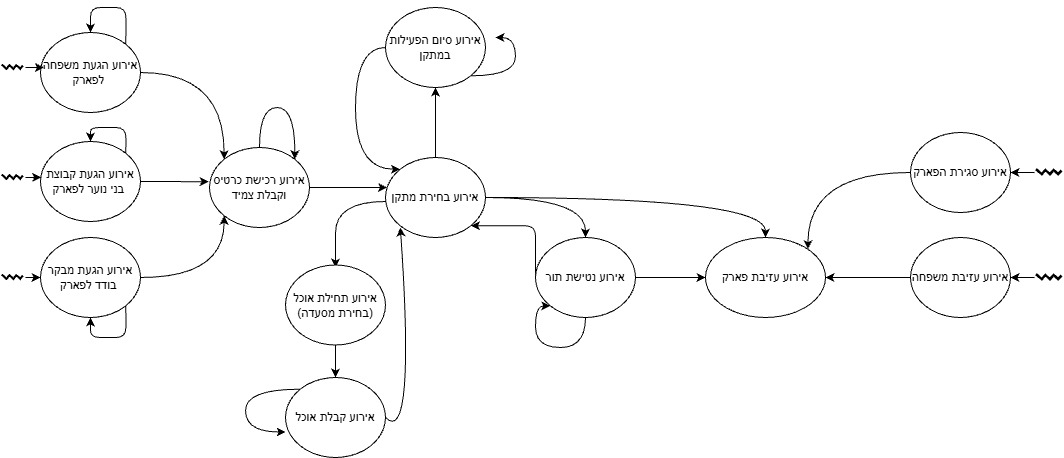

אירוע נטישה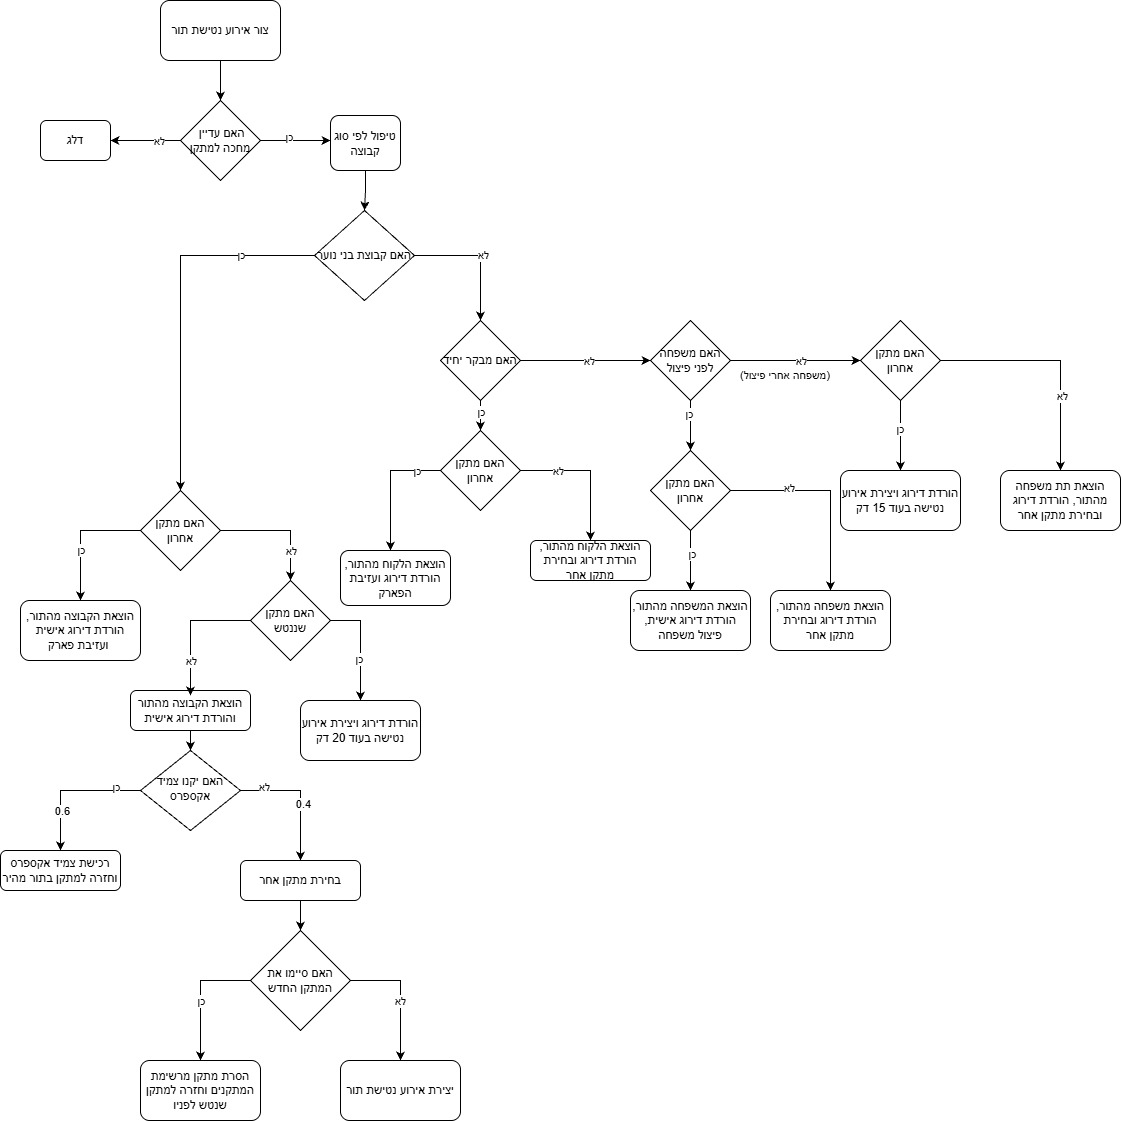

אירוע אכילה


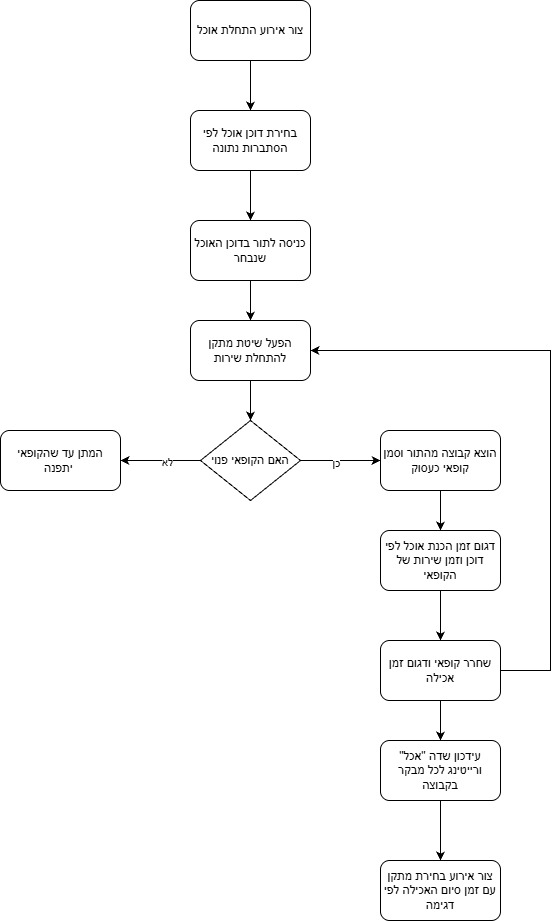


אירוע סגירת פארק

<div dir="rtl">
הנחות:

1. אין אנשים בתורים של דוכני אוכל בשעת סגירת הפארק
2. אם קבוצה נמצאת על מתקן בזמן סגירת הפארק היא תעזוב כשתסיים אותו (באירוע בחירת מתקן ניצור אירוע עזיבה לפי הדגל "פארק סגור")

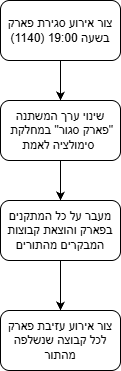

## Objects

###הסבר על האובייקטים בקוד
<div dir="rtl">

## הסבר על האובייקטים בקוד:
**Group:** מייצג את קבוצות המבקרים שמגיעים לפארק. לכל מבקר יש שדה המייצג גיל, שדה המייצג רייטינג אישי אותו הוא מעדכן לאחר פעילויות שונות, שדה המייצג את כמות הכסף שמבקר הוציא ושדה שמייצג האם המבקר אכל.
ישנם שלושה סוגים של קבוצות: משפחה, בני נוער ומבקרים יחידים.
 מחלקת Group כוללת עוד שדות כגון: מתקנים שהקבוצה צריכה לעשות, מתקן שננטש ושדה שאומר כמה זמן הם יחכו עד נטישה, רשימה של חברי הקבוצה, שדה המייצג האם הקבוצה מחזיקה בצמיד אקספרס ושדה שאומר האם הקבוצה צריכה לעזוב. בנוסף, לכל קבוצה קיימת שיטה שבוחרת את המתקן הבא.

**Attraction:** מייצג מתקן בפארק המים. למתקן יש שם, רמת אדרנלין, גיל מינימלי, תור רגיל ואקספרס  של קבוצות מבקרים. בנוסף, לכל מתקן יש שיטות הוספת והוצאת קבוצות מהתור, וכן שיטת הפעלת מתקן הפועלת לפי דגימה מותאמת הקובעת את משך הפעילות בהתאם לסוג המתקן.

**FoodStall:** מייצג דוכן אוכל בפארק. וכולל שדה המייצג את סוג הדוכן: פיצה, המבורגר וסלטים. דוכן אוכל יורש מתקן אך מחזיק תור רגיל בלבד. וגם לו פונקציית דגימה עבור זמן השירות בהתאם לסוג הדוכן.

**Event:** מחלקת אירוע בסיסית אותה כלל האירועים שתכנתנו יורשים, והיא כוללת פונקציית handle על מנת שכלל האירועים שיורשים אותה יממשו אחת כזאת, בהתאם לסוג האירוע.


---

### משאבים
כפי שנכתב בהנחיות, המשאבים בפארק הם 3 פקידי קבלה בכניסה לפארק, 7 מתקנים מסוגים שונים, 3 עמדות אוכל שונות (פיצה, המבורגר וסלטים).
כלל המופעים של האובייקטים נוצרים בתחילת הסימולציה.


---

### הנחות:

* יחידת זמן הסימולציה שנקבעה היא דקה (1 יחידת זמן = 1 דקה). זמני פעילות הפארק הם החל מהדקה ה־ 540 (09:00) עד הדקה ה-1140 (19:00).
* כל סוג קבוצת מבקרים ראשונה מגיעה בתחילת חלון הזמן בו היא יכולה להגיע, בתוספת מספר דקות אותן דוגמים מפונקצייה המייצגת את אלגוריתם הדגימה עבור הגעה של סוג המבקר הספציפי.
* בעת נטישת מתקן אחרון לביצוע, הקבוצה עוזבת את הפארק למעט משפחות להן יש אירוע עזיבה שהוגדר מראש.


### Visitors

####Visitor

In [ ]:
class Visitor:
  def __init__(self, group, age=18, rating=10.0, ate=False ):
      self.age = age
      self.rating = rating
      self.ate = ate
      self.group = group  # always in a group
      self.money_spent = 0.0
      self.attractions_done = 0

  def update_rating_after_ride(self, adrenalin):
    # update rating based on instructions
    if random.random() < 0.5:
        group_size = self.group.size()
        score = ((group_size - 1) / 5) * 0.3 + ((adrenalin - 1) / 4) * 0.7
        self.rating += score
    else:
        self.rating -= 0.1
    self.rating = min(10,self.rating)

####Groups

#####general Group

In [ ]:
class Group:

  def __init__(self, rideslist,group_type,expresspass = False ):
      self.customers = []
      self.all_rides = rideslist
      self.todo_rides = [] # Initialize as empty; subclasses will populate this later
      self.expresspass = expresspass
      self.abandoned_ride = None
      self.group_type = group_type
      self.need_to_leave = False

  def _attach_customer(self, visitor):
    self.customers.append(visitor)

  def size(self):
    return len(self.customers)

  def abandon_ride(self, ride):
    for v in self.customers:
        v.rating -= 0.8
    self.abandoned_ride = ride
    return self.express_after_abandon()

  def finish_attraction(self, ride):
    if ride in self.todo_rides:
      self.todo_rides.remove(ride)
    for v in self.customers:
      v.update_rating_after_ride(ride.adrenalin)
      v.attractions_done += 1

#####Family

In [ ]:
class FamilyGroup(Group):

    def __init__(self, rideslist, expresspass=False):
        super().__init__(rideslist=rideslist,group_type="family" , expresspass=expresspass)
        self.leave_time = SimulationUtils.sample_family_departure_time_minutes()
        self.subgroups = []
        self.has_split = False
        self._create_members() # This populates self.customers
        self.todo_rides = self.filter_rides(self.all_rides) # Now filter_rides is called after customers are ready
        self.max_wait_time = 15

    def _create_members(self):
        # 2 הורים
        super()._attach_customer(Visitor(age=random.randint(25, 55),group = self))
        super()._attach_customer(Visitor(age=random.randint(25, 55),group = self))
        # ילדים
        n = SimulationUtils.sample_num_children()  # 1..5
        for _ in range(n):
            age = int(SimulationUtils.sample_child_age())  # 2..18
            self._attach_customer(Visitor(age=age,group = self))

    def split(self):
        if self.todo_rides:
            return False
        else:
            return True


    def get_sub_groups(self): #splits the family into their respected sub families
        def get_rand_index(n: int) -> int:
            i = int(random.random() * n)
            return n - 1 if i >= n else i

        # 1. Categorize
        escorts  = [v for v in self.customers if v.age >= 12.0]
        teens    = [v for v in self.customers if 8.0 <= v.age < 12.0]
        children = [v for v in self.customers if v.age < 8.0]

        # 2. Determine number of groups
        if len(children) > 0 and len(teens) == 0 and len(escorts) == 2:
            numgroups = 2
        else:
            numgroups = 2 if random.random() < 0.5 else 3

        groups = [[] for _ in range(numgroups)]

        # 3. Step-by-Step Distribution
        for i in range(numgroups):
            if escorts:
                groups[i].append(escorts.pop())
            elif teens:
                groups[i].append(teens.pop())

        escort_group_ids = [i for i, g in enumerate(groups) if any(m.age >= 12.0 for m in g)]

        while children:
            c = children.pop()
            target = escort_group_ids[get_rand_index(len(escort_group_ids))] if escort_group_ids else 0
            groups[target].append(c)

        remaining = escorts + teens
        while remaining:
            target = get_rand_index(numgroups)
            groups[target].append(remaining.pop())

        return groups


    def split_family(self):
      filtered_rides = self.filter_rides(self.all_rides) #refilter all the rides the family did
      rides_that_family_didnt_do = [ride for ride in self.all_rides if ride not in filtered_rides] # save the differece from rideslist
      u = random.random()
      self.has_split = True
      if u <= 0.6:
          groups = self.get_sub_groups()
          for subgroup_customers in groups:
            if subgroup_customers: # Ensure subgroup is not empty before creating SubFamily
              temp = SubFamily(subgroup_customers, rides_that_family_didnt_do,self, self.expresspass)
              for visitor in subgroup_customers:
                visitor.group = temp
              self.subgroups.append(temp)
      else:
          temp = SubFamily(self.customers, rides_that_family_didnt_do,self, self.expresspass)
          for visitor in self.customers:
                visitor.group = temp
          self.subgroups.append(temp)
      self.customers = [] #clear the Original family customers as they have been re assigned

    def choose_next_ride(self, lanchBreak):
        if not self.todo_rides:
            return None
        available_rides = list(self.todo_rides)
        if self.abandoned_ride in available_rides:
            available_rides.remove(self.abandoned_ride)
        if lanchBreak:
          for ride in available_rides:
            if ride.name == "snorkel":
              available_rides.remove(ride)
              break
        if not available_rides:
            return None

        n = len(available_rides)
        u = random.random()
        next_ride = available_rides[int(n*u)]
        self.abandoned_ride = None
        return next_ride

    def filter_rides(self, rideslist):
        allowed = [ride for ride in rideslist if ride.minage is None]
        return allowed

    def express_after_abandon(self):
        return False

#####SubFamily

In [ ]:
class SubFamily(Group):
    def __init__(self, customers, rideslist, parent_family, expresspass=False):
        # rideslist is already prepared in split_family()
        super().__init__(rideslist, group_type="sub_family", expresspass=expresspass)

        self.customers = list(customers) # Ensure self.customers is set BEFORE filtering
        self.parent_family = parent_family
        self.max_wait_time = 15
        self.abandoned_ride = None
        self.todo_rides = self.filter_rides(self.all_rides) # Use self.all_rides and call after customers are set

    def filter_rides(self, rideslist):
        ages = [v.age for v in self.customers]
        if not ages:
            return [] # If no customers, no rides are suitable for this subgroup
        min_age_in_group = min(ages)
        # A ride is allowed if its minimum age requirement is met by the youngest in the group
        # or if the ride has no minimum age requirement.
        allowed = [ride for ride in rideslist if ride.minage is None or min_age_in_group >= ride.minage]
        return allowed

    def choose_next_ride(self, lanchBreak):
      candidates = list(self.todo_rides)

      # don't immediately re-choose the abandoned ride (based on the field in THIS object)
      if self.abandoned_ride in candidates:
          candidates.remove(self.abandoned_ride)
      if lanchBreak:
          for ride in candidates:
            if ride.name == "snorkel":
              candidates.remove(ride)
              break

      if not candidates:
          return None

      # choose the shortest relevant queue using the ride API you specified
      if self.expresspass:
          best_size = min(r.get_express_queue_size() for r in candidates)
          best = [r for r in candidates if r.get_express_queue_size() == best_size]
      else:
          best_size = min(r.get_total_queue_size() for r in candidates)
          best = [r for r in candidates if r.get_total_queue_size() == best_size]

      u = random.random()
      return best[int(u * len(best))]

    def express_after_abandon(self):
        return False

#####Teens



In [ ]:
class TeenGroup(Group):

  def __init__(self, rideslist, expresspass=False):
    super().__init__(rideslist=rideslist,group_type="teen" , expresspass=expresspass)
    self._create_members() # This populates self.customers
    self.todo_rides = self.filter_rides(self.all_rides) # Now filter_rides is called after customers are ready
    self.max_wait_time = 20

  def _create_members(self):
    size = SimulationUtils.sample_teens_group_size()
    for _ in range(size):
      self._attach_customer(Visitor(age=random.randint(14, 18),group=self))
  def split(self):
    return False
  def express_after_abandon(self):
        u = random.random()
        if u <= 0.6:
          self.expresspass = True
          for customer in self.customers:
            customer.money_spent +=50
          return True
        else:
          return False

  def choose_next_ride(self, lanchBreak):
    if not self.todo_rides:
        return None
  #creating a cop of todo to remove the abandoned ride not permenantly
    available_rides = list(self.todo_rides)
    if self.abandoned_ride in available_rides:
        available_rides.remove(self.abandoned_ride)
    if lanchBreak:
          for ride in available_rides:
            if ride.name == "snorkel":
              available_rides.remove(ride)
              break
    if not available_rides:
        return None

    n = len(available_rides)
    u = random.random()
    return available_rides[int(n * u)]

  def filter_rides(self, rideslist):
    allowed = [ride for ride in rideslist if ride.adrenalin >= 3]
    return allowed

#####Single

In [ ]:
class SingleGroup(Group):

  def __init__(self, rideslist, expresspass=False):
    super().__init__(rideslist= rideslist,group_type="single" , expresspass= expresspass)
    self._attach_customer(Visitor(age=random.randint(18, 30),group=self)) # This populates self.customers
    self.todo_rides = self.filter_rides(self.all_rides) # Now filter_rides is called after customers are ready
    self.max_wait_time = 30

  def filter_rides(self, rideslist):
    allowed = [ride for ride in rideslist if getattr(ride, "maxage", None) is None]
    return allowed

  def choose_next_ride(self, lanchBreak):
    if not self.todo_rides:
        return None
    available_rides = list(self.todo_rides)
    if self.abandoned_ride in available_rides:
      available_rides.remove(self.abandoned_ride)
    if lanchBreak:
      for ride in available_rides:
        if ride.name == "snorkel":
          available_rides.remove(ride)
          break
    if not available_rides:
      return None
    above_12 = [r for r in available_rides if (r.minage is not None and r.minage >= 12)]
    if above_12 == []: ## choose from all available in todo in equal probability
      self.abandoned_ride = None
      return self.min_q_ride(available_rides)
    else:
      self.abandoned_ride = None
      return self.min_q_ride(above_12)

  def split(self):
    return False
  def min_q_ride(self, chosen_rides):
    chosen_ride = None
    minq = float("inf")
    if self.expresspass:
      for ride in chosen_rides:
        if ride.get_express_queue_size() < minq:
          chosen_ride = ride
          minq = ride.get_express_queue_size()
    else:
        for ride in chosen_rides:
            if ride.get_total_queue_size()  < minq:
              chosen_ride = ride
              minq = ride.get_total_queue_size()
    return chosen_ride

  def express_after_abandon(self):
    return False

###Attractions

####General Attraction

In [ ]:
class Attraction():
  def __init__(self,name,adrenalin,minage = None):
    self.name = name
    self.minage = minage
    self.adrenalin = adrenalin
    self.queue = []
    self.queue_size = 0
    self.expressqueue = []
    self.expressqueue_size = 0
    self.abandons = 0
    self.entered_queue = 0

  def enqueue(self, group, time):
    if group == None:
      return
    if group.expresspass:
      self.expressqueue.append(group)
      self.expressqueue_size += group.size()
      return True
    else:
      self.queue.append(group)
      self.queue_size += group.size()
      self.entered_queue += group.size()
      return True

  def pop_next_group(self):
    if self.expressqueue:
      g = self.expressqueue.pop(0)
      self.expressqueue_size -= g.size()
      return g
    if self.queue:
      g = self.queue.pop(0)
      self.queue_size -= g.size()
      return g
    return None

  def start_service(self,time):
    raise NotImplementedError()

  def release_resources(self,free_resources):
    raise NotImplementedError()

  def get_queue_size(self):
    return self.queue_size

  def get_express_queue_size(self):
    return self.expressqueue_size

  def get_total_queue_size(self):
    return self.expressqueue_size + self.queue_size

####Tube River

In [ ]:
class tube_river(Attraction):
    def __init__(self):  # unless specified otherwise, 60 tubes
        super().__init__("tube_river", 1)
        self.total_tubes = 60
        self.available_tubes = 60
        self.seats_per_tube = 2

    def tubes_needed(self, group):
        return math.ceil(group.size() / self.seats_per_tube)

    def can_start_service(self):
        return self.available_tubes > 0 and (len(self.expressqueue) > 0 or len(self.queue) > 0)

    def pop_first_single(self, q_list, q_size_attr):
        """
        Pop the first single-visitor group from the given queue list.
        queue_size counters represent VISITORS (not groups).
        """
        for i, g in enumerate(q_list):
            if g.size() == 1:
                popped = q_list.pop(i)
                setattr(self, q_size_attr, getattr(self, q_size_attr, 0) - popped.size())  # -1, but invariant-safe
                return popped
        return None

    def load_groups_from_queue(self, queue_list, queue_size_attr, tubes_being_used):
        """
        Scan ahead (allowed by instructions): take any group that fits remaining tubes.
        Removes selected groups from the queue and updates the queue-size counter in VISITORS.
        Returns: (loaded_groups, updated_tubes_being_used)
        """
        loaded = []
        to_remove = []

        for g in queue_list:
            needed = self.tubes_needed(g)
            if self.available_tubes - tubes_being_used >= needed:
                loaded.append(g)
                to_remove.append(g)
                tubes_being_used += needed

        for g in to_remove:
            queue_list.remove(g)

        # IMPORTANT: counters are VISITORS, not groups
        setattr(self, queue_size_attr, sum(grp.size() for grp in queue_list))

        return loaded, tubes_being_used

    def fill_empty_seats_with_singles(self, empty_seats):
        """
        Try to fill empty seats using single visitors, prioritizing express queue.
        Returns a list of single-visitor groups that were pulled from queues.
        """
        fillers = []
        while empty_seats > 0:
            single = self.pop_first_single(self.expressqueue, 'expressqueue_size')
            if single is None:
                single = self.pop_first_single(self.queue, 'queue_size')

            if single is None:
                break

            fillers.append(single)
            empty_seats -= 1

        return fillers

    def start_service(self, current_time):
        if not self.can_start_service():
            return None

        tubes_being_used = 0
        selected_groups = []

        # 1) Load from express queue
        groups, tubes_being_used = self.load_groups_from_queue(
            self.expressqueue, 'expressqueue_size', tubes_being_used
        )
        selected_groups.extend(groups)

        # 2) Load from regular queue
        groups, tubes_being_used = self.load_groups_from_queue(
            self.queue, 'queue_size', tubes_being_used
        )
        selected_groups.extend(groups)

        if not selected_groups:
            return None

        # 3) Fill empty seats with singles
        actual_people_loaded = sum(g.size() for g in selected_groups)
        empty_seats = (tubes_being_used * self.seats_per_tube) - actual_people_loaded

        fillers = self.fill_empty_seats_with_singles(empty_seats)
        groups_on_ride = selected_groups + fillers

        # Reserve tubes for this batch
        self.available_tubes -= tubes_being_used

        duration = SimulationUtils.sample_river_tube_duration()
        end_time = current_time + duration

        return groups_on_ride, end_time, tubes_being_used

    def release_resources(self, used_tubes):
        used_tubes = used_tubes or 0
        self.available_tubes = min(self.total_tubes, self.available_tubes + used_tubes)

####Single Slides

In [ ]:
class single_slide(Attraction):
    def __init__(self):
        super().__init__(name="single_slide", adrenalin=5, minage=14)

        self.entry_gap = 0.5
        self.ride_duration = 3.0
        self.num_lanes = 2

        self.next_lane_start = [540] * self.num_lanes

        # ramp acting as an intermidiate queue to pull from group members
        self.ramp_group = None

    def _has_waiting(self):
        return bool(self.expressqueue or self.queue)

    def can_start_service(self, current_time):
        return self.ramp_group is None and self._has_waiting()

    def next_start_time(self, current_time): #calculates the start time of the next group
        if self.ramp_group is not None or not self._has_waiting():
            return None
        t_lane = min(t + self.entry_gap for t in self.next_lane_start)
        return max(current_time, t_lane)

    def start_service(self, current_time):
        if not self.can_start_service(current_time):
            return None

        group = self.pop_next_group()
        self.ramp_group = group   # load to ramp
        if(self in group.todo_rides):
          group.todo_rides.remove(self)
        last_finish = -math.inf

        # assign to two slides
        for _ in group.customers:
            lane_idx = min(range(self.num_lanes), key=lambda i: self.next_lane_start[i])
            start_t = max(current_time, self.next_lane_start[lane_idx] + self.entry_gap)
            finish_t = start_t + self.ride_duration

            self.next_lane_start[lane_idx] = start_t
            last_finish = max(last_finish, finish_t)

        end_time = last_finish
        return [group], end_time, None

    def release_resources(self, meta=None):
        # leave ramp
        self.ramp_group = None
        return

####Big Tube

In [ ]:
class big_tube(Attraction):
  def __init__(self, tube_capacity=8):
        super().__init__(name="big_tube", adrenalin=2)
        self.tube_capacity = tube_capacity
        self.busy = False


  def can_start_service(self, current_time=None):
  # can start if not busy and at least one group is waiting
    return (not self.busy) and (self.expressqueue_size + self.queue_size > 0)

  def _find_first_fit_index(self, q, remaining):
      """Return index of first group in q that fits remaining seats, else None."""
      for i, g in enumerate(q):
          if len(g.customers) <= remaining:
              return i
      return None

  def sample_duration(self):
      # Resample until positive (your sampler can be negative sometimes)
      while True:
          d = SimulationUtils.sample_big_tube_duration()
          if d is not None and d > 0:
              return d

  def start_service(self, current_time):
      if not self.can_start_service(current_time):
          return None

      selected = []
      loaded = 0
      remaining = self.tube_capacity

      # Keep loading while you can fit someone into remaining seats
      while remaining > 0:
          idx = self._find_first_fit_index(self.expressqueue, remaining)
          if idx is not None:
            g = self.expressqueue.pop(idx)
            self.expressqueue_size -= g.size() # Fixed: Decrement size
            selected.append(g)
            loaded += g.size()
            remaining -= g.size()
            continue

          idx = self._find_first_fit_index(self.queue, remaining)
          if idx is not None:
            g = self.queue.pop(idx)
            self.queue_size -= g.size() # Fixed: Decrement size
            selected.append(g)
            loaded += g.size()
            remaining -= g.size()
            continue

          # Nobody fits the remaining seats (e.g., remaining=1 but only couples left)
          break

      # If we couldn't load anyone at all, don't start
      # (shouldn't happen unless queues are empty or all groups > capacity)
      if loaded == 0:
          return None

      self.busy = True
      end_time = current_time + self.sample_duration()

      # meta not needed here; busy flag is enough
      return selected, end_time, None

  def release_resources(self, meta=None):
    self.busy = False

####Small Tube

In [ ]:
class small_tube(Attraction):
    def __init__(self, tube_capacity=3, num_tubes=1):
        super().__init__(name="small_tube", adrenalin=4, minage=12)

        self.tube_capacity = tube_capacity
        self.num_tubes = num_tubes
        self.busy_tubes = [False] * num_tubes

        # ramp/platform supports multiple groups
        self.ramp = []                 # ordered groups on ramp
        self._ramp_next_idx = {}       # group -> next customer index to send
        self.ramp_people = 0           # how many riders remain on ramp

    def _any_tube_free(self):
        return any(not b for b in self.busy_tubes)

    def _claim_free_tube(self):
        for i in range(self.num_tubes):
            if not self.busy_tubes[i]:
                self.busy_tubes[i] = True
                return i
        return None

    def _has_waiting(self):
        return bool(self.expressqueue or self.queue)

    def can_start_service(self, current_time=None):
        return self._any_tube_free() and (self.ramp_people > 0 or self._has_waiting())

    def _push_group_to_ramp(self, g):
        if g in self._ramp_next_idx:
            return
        self.ramp.append(g)
        if(self in g.todo_rides):
          g.todo_rides.remove(self)
        self._ramp_next_idx[g] = 0
        self.ramp_people += len(g.customers)

    def _fill_ramp_until(self, target_people):
        # express first
        while self.ramp_people < target_people and self._has_waiting():
            if self.expressqueue:
                g = self.expressqueue.pop(0)
                self.expressqueue_size -= g.size() # remove from queue
            else:
                g = self.queue.pop(0)
                self.queue_size -= g.size() #remove from queue
            self._push_group_to_ramp(g)

    def _take_from_front_ramp(self, seats_left):
        """
        Take up to seats_left from the first group on ramp.
        Returns: (taken_count, group, finished_now)
        """
        if not self.ramp:
            return 0, None, False

        g = self.ramp[0]
        idx = self._ramp_next_idx[g]

        remaining_in_group = len(g.customers) - idx
        take = min(seats_left, remaining_in_group)

        self._ramp_next_idx[g] = idx + take
        self.ramp_people -= take

        finished = (self._ramp_next_idx[g] >= len(g.customers))
        if finished:
            self.ramp.pop(0)
            del self._ramp_next_idx[g]

        return take, g, finished

    def sample_duration(self):
        return SimulationUtils.sample_small_tube_duration()

    def start_service(self, current_time):
        if not self.can_start_service(current_time):
            return None

        tube_idx = self._claim_free_tube()
        if tube_idx is None:
            return None

        # try to stage enough people to fill 3 seats (if possible)
        self._fill_ramp_until(self.tube_capacity)

        seats_left = self.tube_capacity
        groups_touched = []        # groups that contributed riders this round
        groups_completed = set()   # groups that finished ALL members this round

        while seats_left > 0 and self.ramp_people > 0:
            took, g, finished = self._take_from_front_ramp(seats_left)
            if took <= 0:
                break

            seats_left -= took

            if g is not None and g not in groups_touched:
                groups_touched.append(g)
            if finished and g is not None:
                groups_completed.add(g)

        # if loaded nobody -> undo and abort
        if not groups_touched:
            self.busy_tubes[tube_idx] = False
            return None

        end_time = current_time + self.sample_duration()
        meta = {"tube_idx": tube_idx, "groups_completed": list(groups_completed)}

        # IMPORTANT: return GROUPS to match your existing StartRide/FinishRide logic
        return groups_touched, end_time, meta

    def release_resources(self, meta=None):
        if meta is None:
            for i in range(self.num_tubes):
                if self.busy_tubes[i]:
                    self.busy_tubes[i] = False
                    return
        tube_idx = meta.get("tube_idx", None) if meta else None
        if tube_idx is not None:
            self.busy_tubes[tube_idx] = False

####Wave Pool

In [ ]:
class wave_pool(Attraction):
    def __init__(self, capacity=80):
        super().__init__(name="wave_pool", adrenalin=3, minage=12)
        self.capacity = capacity
        self.occupancy = 0   # number of people currently inside

    def _find_first_fit_index(self, q, remaining):
        for i, g in enumerate(q):
            if len(g.customers) <= remaining:
                return i
        return None

    def can_start_service(self, current_time=None):
        remaining = self.capacity - self.occupancy
        if remaining <= 0:
            return False
        # can start if ANY group fits (because skipping is allowed)
        return (any(len(g.customers) <= remaining for g in self.expressqueue) or
                any(len(g.customers) <= remaining for g in self.queue))

    def sample_duration(self):
        return SimulationUtils.sample_wave_pool_duration()

    def start_service(self, current_time):
        if not self.can_start_service(current_time):
            return None

        selected = []
        remaining = self.capacity - self.occupancy

        # batch admission with "skip-fit" logic
        while remaining > 0:
            idx = self._find_first_fit_index(self.expressqueue, remaining)
            if idx is not None:
                g = self.expressqueue.pop(idx)
                self.expressqueue_size -= g.size() # Fixed: Decrement size
                selected.append(g)
                s = len(g.customers)
                self.occupancy += s
                remaining -= s
                continue

            idx = self._find_first_fit_index(self.queue, remaining)
            if idx is not None:
                g = self.queue.pop(idx)
                self.queue_size -= g.size() # Fixed: Decrement size
                selected.append(g)
                s = len(g.customers)
                self.occupancy += s
                remaining -= s
                continue

            # nobody fits remaining space
            break

        if not selected:
            return None

        end_time = current_time + self.sample_duration()

        # meta = selected groups so we can release exact people on finish
        meta = selected
        return selected, end_time, meta

    def release_resources(self, meta=None):
        if meta is None:
            return
        for g in meta:
            self.occupancy -= len(g.customers)
        if self.occupancy < 0:
            self.occupancy = 0

####Kids Pool

In [ ]:
class kid_pool(Attraction):
    def __init__(self, capacity_kids=30):
        super().__init__(name="kids_pool", adrenalin=1, minage=0)
        self.capacity_kids = capacity_kids
        self.occupancy_kids = 0  # how many kids (<=4) are inside

    def kids_in_group(self, g):
        # counts only kids eligible for the pool
        # assumes customer has .age
        return sum(1 for c in g.customers if c.age <= 4)

    def _find_first_fit_index_kids(self, q, remaining_kids):
        for i, g in enumerate(q):
            k = self.kids_in_group(g)
            if 0 < k <= remaining_kids:
                return i
        return None

    def can_start_service(self, current_time=None):
        remaining = self.capacity_kids - self.occupancy_kids
        if remaining <= 0:
            return False
        return (any(0 < self.kids_in_group(g) <= remaining for g in self.expressqueue) or
                any(0 < self.kids_in_group(g) <= remaining for g in self.queue))

    def start_service(self, current_time):
        if not self.can_start_service(current_time):
            return None

        selected = []
        meta = []
        remaining = self.capacity_kids - self.occupancy_kids

        while remaining > 0:
            idx = self._find_first_fit_index_kids(self.expressqueue, remaining)
            if idx is not None:
                g = self.expressqueue.pop(idx)
                self.expressqueue_size -= g.size() # Fixed: Decrement size
            else:
                idx = self._find_first_fit_index_kids(self.queue, remaining)
                if idx is None:
                    break
                g = self.queue.pop(idx)
                self.queue_size -= g.size() # Fixed: Decrement size

            k = self.kids_in_group(g)
            selected.append(g)
            meta.append((g, k))

            self.occupancy_kids += k
            remaining -= k

        if not selected:
            return None

        duration = SimulationUtils.sample_kids_pool_duration_minutes()  # already minutes
        end_time = current_time + duration

        return selected, end_time, meta

    def release_resources(self, meta=None):
        if not meta:
            return
        for (g, k) in meta:
            self.occupancy_kids -= k
        if self.occupancy_kids < 0:
            self.occupancy_kids = 0

####Snorkel

In [ ]:
class snorkel(Attraction):
    def __init__(self, num_guides=2, max_people=30):
        super().__init__(name="snorkel", adrenalin=3, minage=6)
        self.num_guides = num_guides
        self.max_people = max_people

        self.busy_guides = [False] * num_guides
        self.next_free_time = [0.0] * num_guides  # cooldown tracking

        # minutes since 09:00
        self.break_start = 780
        self.break_end = 840
        self.cooldown = 30  # minutes between tours

    def _in_break(self, t):
        return self.break_start <= t < self.break_end

    def _any_guide_free(self, t):
        for i in range(self.num_guides):
            if (not self.busy_guides[i]) and (t >= self.next_free_time[i]):
                return True
        return False

    def _claim_free_guide(self, t):
        for i in range(self.num_guides):
            if (not self.busy_guides[i]) and (t >= self.next_free_time[i]):
                self.busy_guides[i] = True
                return i
        return None

    def _find_first_fit_index(self, q, remaining):
        for i, g in enumerate(q):
            if len(g.customers) <= remaining:
                return i
        return None

    def _sample_duration_positive(self):
        #sampler can return negative; resample until positive
        while True:
            d = SimulationUtils.sample_snorkel_duration()
            if d is not None and d > 0:
                return d

    def can_start_service(self, current_time=None):
        if current_time is None:
            return False
        if self._in_break(current_time):
            return False
        if not self._any_guide_free(current_time):
            return False
        if (self.queue_size + self.expressqueue_size >= 0):
            return True
        return False


    def start_service(self, current_time):
        if not self.can_start_service(current_time):
            return None

        guide_idx = self._claim_free_guide(current_time)
        if guide_idx is None:
            return None

        selected = []
        loaded = 0
        remaining = self.max_people

        duration = self._sample_duration_positive()
        if (current_time + duration > self.break_start and current_time + duration < self.break_end):
          self.busy_guides[guide_idx] = False
          return None



        while remaining > 0:
            idx = self._find_first_fit_index(self.expressqueue, remaining)
            if idx is not None:
                g = self.expressqueue.pop(idx)
                self.expressqueue_size -= g.size()
            else:
                idx = self._find_first_fit_index(self.queue, remaining)
                if idx is None:
                    break
                g = self.queue.pop(idx)
                self.queue_size -= g.size()

            s = len(g.customers)
            selected.append(g)
            loaded += s
            remaining -= s

        if loaded == 0:
            self.busy_guides[guide_idx] = False
            return None


        end_time = current_time + duration


        meta = {"guide_idx": guide_idx, "finish_time": end_time}
        return selected, end_time, meta

    def release_resources(self, meta=None):
        if not meta:
            return
        guide_idx = meta.get("guide_idx", None)
        finish_time = meta.get("finish_time", None)
        if guide_idx is None:
            return

        self.busy_guides[guide_idx] = False

        # 30-minute break between tours
        if finish_time is not None:
            self.next_free_time[guide_idx] = finish_time + self.cooldown

####Box Office

In [ ]:
class BoxOffice(Attraction):
    def __init__(self, website, num_clerks=3):
        super().__init__(name="box_office", minage=0, adrenalin=0)
        self.total_clerks = num_clerks
        self.free_clerks = num_clerks
        self.queue = []
        self.queue_size = 0
        self.website = website
        self.total_visitors = 0


    def can_start_service(self):
        return self.free_clerks > 0 and len(self.queue) > 0

    def calculate_price(self, visitor):
        if(visitor.age > 14 ):
            return 150
        if(visitor.age > 2):
            return 75
        return 0


    def start_service(self, current_time):
        started = []

        while self.can_start_service():
            group = self.queue.pop(0)
            self.queue_size -= group.size()
            self.free_clerks -= 1
            if(random.random()<=0.25):
               group.expresspass = True
               for visitor in group.customers:
                   visitor.money_spent += (self.calculate_price(visitor)+50)
            else:
               for visitor in group.customers:
                   visitor.money_spent += (self.calculate_price(visitor))

            self.total_visitors+=group.size()

            bracelet_time = SimulationUtils.sample_bracelet_recive_duration()
            service_time = self.calcServiceTime()
            finish_time = current_time + service_time +bracelet_time

            started.append((group, finish_time))

        return started

    def release_resources(self):
        self.free_clerks = min(self.total_clerks, self.free_clerks + 1)

    def calcServiceTime(self):
      if self.website:
        return 0
      else:
        return SimulationUtils.sample_ticket_buying_duration()


####Food Stall

In [ ]:
class FoodStall(Attraction):
    def __init__(self, name, min_prep, max_prep, dish_cost):
        super().__init__(name=name, adrenalin=0, minage=0)
        self.min_prep = min_prep
        self.max_prep = max_prep
        self.busy = False
        self.current_group = None
        self.dish_cost = dish_cost

    #overloading regular enqueue to remove express option
    def enqueue(self, group, time):
        self.queue.append((group, time))
        self.queue_size += 1

    def sample_service_time(self, group):
        prep_per_unit = SimulationUtils.sample_food_preparation_time(self.min_prep, self.max_prep)
        prep_total = prep_per_unit * group.size()
        cashier_time = SimulationUtils.sample_cashier_service_time()
        return prep_total + cashier_time

    def charge_group(self, group):
        for v in group.customers:
            v.money_spent += self.dish_cost

    def start_service(self, time):
        """
        just like an attraction
        """
        if self.busy or not self.queue:
            return ([], None, None)

        (grp, _arrival_time) = self.queue.pop(0)
        self.queue_size -= 1

        self.busy = True
        self.current_group = grp
        self.charge_group(grp)

        end_time = time + self.sample_service_time(grp)

        meta = None
        return (grp, end_time, meta)

    def release_resources(self, meta=None):
        self.busy = False
        self.current_group = None

In [ ]:
class Pizza(FoodStall):
    def __init__(self):
        super().__init__("Pizza", min_prep=4, max_prep=6, dish_cost=40)
        self.family_dish_cost= 100

    def charge_group(self, group):
      if group.size()>1:
        for v in group.customers:
            v.money_spent+= self.family_dish_cost/group.size() #Paying their relative share of the price
      else:
        for v in group.customers:
          v.money_spent+= self.dish_cost

    def sample_service_time(self, group): #same time for personal or family pizza
        cashier_time = SimulationUtils.sample_cashier_service_time()
        prep_total = SimulationUtils.sample_food_preparation_time(self.min_prep, self.max_prep)
        return prep_total + cashier_time


class Burger(FoodStall):
    def __init__(self):
        super().__init__("Burger" ,min_prep=3, max_prep=4, dish_cost=100)


class Salad(FoodStall):
    def __init__(self):
        super().__init__("Salad", min_prep=3 , max_prep=7, dish_cost=65)

### Events

####General Event

In [ ]:
class Event:
  def __init__(self, time, group = None):
      self.time = time
      self.group = group


  def handle(self, simulation):
      raise NotImplementedError

  def __lt__(self, other):
      return self.time < other.time


####Event Queue

In [ ]:
class EventQueue:
    def __init__(self):
        self.events = []
        self.max_time = 1340

    def add_event(self, event):
        if event.time > self.max_time:
            return
        heapq.heappush(self.events,event)

    def pop_next_event(self):
        if self.events:
          event = heapq.heappop(self.events)
            # We stored (time, counter, event), so we pop the event itself
          return event
        return None

    def is_empty(self):
        return len(self.events) == 0

    def peek_next_time(self):
        if self.events:
            return self.events[0][0]
        return float('inf')

#### Arrival Event
Customers Arriving to the park

In [ ]:
class ArrivalEvent(Event):
    def __init__(self, time, customer_type, rideslist):
        super().__init__(time)
        self.customer_type = customer_type  # "family" / "teens" / "single"
        self.rideslist = rideslist
    def handle(self, simulation):
        t = self.time
        if self.customer_type == "family":
            end = 720
            if t > end:
                return

            t_next = t + SimulationUtils.sample_interarrival_family()
            if t_next <= end:
                simulation.event_diary.add_event(ArrivalEvent(t_next, "family",self.rideslist))

            group = FamilyGroup(self.rideslist)
            # Schedule the FamilyLeaveEvent here based on the group's sampled leave_time
            simulation.event_diary.add_event(FamilyLeaveEvent(group.leave_time, group))
            simulation.event_diary.add_event(StartTicketPurchaseEvent(t, group))

        elif self.customer_type == "teens":
            start, end = 600, 960
            if t < start:
                t = start
            if t > end:
                return

            t_next = t + SimulationUtils.sample_interarrival_teens()
            if t_next <= end:
                simulation.event_diary.add_event(ArrivalEvent(t_next, "teens",self.rideslist))

            group = TeenGroup(self.rideslist)
            simulation.event_diary.add_event(StartTicketPurchaseEvent(t, group))

        elif self.customer_type == "single":
            end = 1110
            if t > end:
                return
            if not simulation.alt_arrivals:
              t_next = t + SimulationUtils.sample_interarrival_single_reg()
            else:
              t_next = t + SimulationUtils.sample_interarrival_single_alt()
            if t_next <= end:
                simulation.event_diary.add_event(ArrivalEvent(t_next, "single",self.rideslist))

            group = SingleGroup(self.rideslist)
            simulation.event_diary.add_event(StartTicketPurchaseEvent(t, group))

#### Ticket Purchase Event

In [ ]:
class StartTicketPurchaseEvent(Event):
    def __init__(self, time, group=None):
        super().__init__(time,group)

    def handle(self, sim):
        # If called with a group (arrival), enqueue it
        if self.group is not None:
            sim.box_office.enqueue(self.group,self.time)

        # Start as many services as possible
        started = sim.box_office.start_service(sim.time)
        for g, finish_time in started:
            sim.event_diary.add_event(FinishTicketPurchaseEvent(finish_time, g))



class FinishTicketPurchaseEvent(Event):
    def __init__(self, time, group):
        super().__init__(time)
        self.group = group

    def handle(self, sim):
        sim.box_office.release_resources()
        for v in self.group.customers:
          sim.stats["total_visitors"]+=1
        # group continues to park
        sim.event_diary.add_event(ChooseNextAttractionEvent(sim.time, self.group))

        # now that a clerk freed, try to start again (no new group)
        #sim.event_diary.add_event(StartTicketPurchaseEvent(sim.time)) ## לא בטוח?

####Abandon event




In [ ]:
class AbandonQueueEvent(Event):
    PENALTY_LAST_RIDE = 0.8

    def __init__(self, time, group, ride):
        super().__init__(time, group)
        self.ride = ride

    # -------------------------
    # Main handler
    # -------------------------
    def handle(self, sim):
        if not self._should_process():
            return
        gtype = self.group.group_type

        if gtype == "teen":
            self._handle_teen(sim)
        elif gtype == "family":
            self._handle_family(sim)
        elif gtype == "sub_family":
            self._handle_sub_family(sim)
        else:
            self._handle_single(sim)


    # -------------------------
    # Helpers: validation & type
    # -------------------------
    def _should_process(self):
      g = self.group
      r = self.ride
      if g is None:
          return False
      if g.expresspass is True:
          return False
      if r not in g.todo_rides:
          return False
      if g not in self.ride.queue:
          return False
      if g.need_to_leave:
          return False
      return True

    def _is_last_ride(self):
        return len(self.group.todo_rides) <= 1

    def _has_subgroups(self):
        # your rule: after diverge => subgroups list not empty
        return self.group.has_split


    # -------------------------
    # Helpers: common actions
    # -------------------------
    def _leave_now(self, sim):
        for v in self.group.customers:
          v.rating-=self.PENALTY_LAST_RIDE
        if self.group in self.ride.queue:
          self.ride.queue.remove(self.group)
          self.ride.abandons+=self.group.size()
        sim.event_diary.add_event(LeaveParkEvent(sim.time, self.group))

    def _choose_next(self, sim):
        sim.event_diary.add_event(ChooseNextAttractionEvent(sim.time, self.group))

    def _start_same_ride(self, sim):
        sim.event_diary.add_event(StartRideEvent(sim.time, self.ride, self.group))

    # -------------------------
    # Logic per group type
    # -------------------------
    def _handle_teen(self, sim):
        # Teen: last ride => -0.8 and leave
        if self._is_last_ride():
            self._leave_now(sim)
            return

        # Otherwise: abandon_ride decides express or not
        if (self.ride == self.group.abandoned_ride):
          self.group.abandon_ride(self.ride)
          sim.event_diary.add_event(AbandonQueueEvent(sim.time+ self.group.max_wait_time, self.group,self.ride))
        else:
          bought_express = self.group.abandon_ride(self.ride)  # should lower rating inside
          if bought_express:
              self.group.abandoned_ride = None
              if self.group in self.ride.queue:
                self.ride.queue.remove(self.group)
                self.ride.abandons+=self.group.size()
              self.ride.abandons+=self.group.size()
              self._start_same_ride(sim)
          else:
              if self.group in self.ride.queue:
                self.ride.queue.remove(self.group)
                self.ride.abandons+=self.group.size()
              self.ride.abandons+=self.group.size()
              self._choose_next(sim)

    def _handle_family(self, sim):
        # Families BEFORE diverge (subgroups empty):
        if not self._has_subgroups():
            self.ride.queue.remove(self.group)
            self.ride.abandons+=self.group.size()
            if self._is_last_ride():
                # last ride before diverging:
                # split + abandon + schedule subfamilies to choose next
                self.group.abandon_ride(self.ride)
                self.group.split_family()

                # If split_family doesn't return, use group.subgroups
                subs = self.group.subgroups

                for sg in subs:
                    sim.event_diary.add_event(ChooseNextAttractionEvent(sim.time, sg))
                return

            # not last: lower grade and proceed
            self.group.abandon_ride(self.ride)
            self._choose_next(sim)
            return

        # If family object still receives abandon after diverge, treat like sub-family:
        self._handle_sub_family(sim)

    def _handle_sub_family(self, sim):
        # Sub-family: not last => lower + choose next
        if not self._is_last_ride():
            self.group.abandon_ride(self.ride)
            self._choose_next(sim)
            return


        self.group.abandon_ride(self.ride)  # penalty
        sim.event_diary.add_event(AbandonQueueEvent(sim.time + self.group.max_wait_time, self.group, self.ride))

    def _handle_single(self, sim):
        # Single: not last => lower + choose next, last => lower + leave
        if self._is_last_ride():
            self._leave_now(sim)
            return

        self.group.abandon_ride(self.ride)
        self.ride.queue.remove(self.group)
        self.ride.abandons+=self.group.size()
        self._choose_next(sim)


#### Start Ride Event

In [ ]:
class StartRideEvent(Event):
    def __init__(self, time, ride, group=None):
        super().__init__(time, group)
        self.ride = ride

    def _already_waiting_somewhere(self):
        g = self.group
        r = self.ride
        if g is None:
            return False

        # single_slide ramp
        if getattr(r, "ramp_group", None) is g:
            return True

        # small_tube ramp list
        ramp = getattr(r, "ramp", None)
        if ramp is not None and g in ramp:
            return True

        # queues (store Group objects in your code)
        if g in getattr(r, "expressqueue", []):
            return True
        if g in getattr(r, "queue", []):
            return True

        return False

    def handle(self, sim):
        if self.group is None:
            return
        ##if(self.time > 1300):
          ##print("hello the time is : " + str(self.time)+ " , and the group is : " +str(self.group.group_type) + " , and the event is : " + "start ride")
        # enqueue only if not already waiting (prevents single_slide double enqueue)
        if not self._already_waiting_somewhere():
            self.ride.enqueue(self.group, self.time)

            if (self.group.expresspass is False) and (self.ride in self.group.todo_rides):
                abandontime = self.time + self.group.max_wait_time
                sim.event_diary.add_event(AbandonQueueEvent(abandontime, self.group, self.ride))

        # single_slide may need to wait for the next allowed start time
        if self.ride.name == "single_slide":
            t_next = self.ride.next_start_time(self.time)
            if t_next is not None and t_next != self.time:
                sim.event_diary.add_event(StartRideEvent(t_next, self.ride, self.group))
                return

        res = self.ride.start_service(self.time)
        if res is None:
            return

        groups_on_ride, end_time, meta = res

        # Which groups truly completed this attraction in THIS batch?
        if meta and isinstance(meta, dict) and "groups_completed" in meta:
            completed_set = set(meta["groups_completed"])
        else:
            completed_set = set(groups_on_ride)

        # schedule FinishRideEvent for completed groups only
        first = True
        for g in groups_on_ride:
            if g not in completed_set:
                continue

            g.finish_attraction(self.ride)
            sim.event_diary.add_event(
                FinishRideEvent(
                    end_time,
                    self.ride,
                    g,
                    batch_meta=meta if first else None,
                    is_leader=first
                )
            )
            first = False

        # IMPORTANT: if nobody completed (can happen in small_tube when big group is still ongoing),
        # still schedule ONE leader to release resources and keep the system moving.
        if first:
            sim.event_diary.add_event(
                FinishRideEvent(end_time, self.ride, self.group, batch_meta=meta, is_leader=True)
            )


#### Finish Ride Event

In [ ]:
class FinishRideEvent(Event):
    def __init__(self, time, ride, group, batch_meta=None, is_leader=False):
        super().__init__(time)
        self.ride = ride
        self.group = group
        self.batch_meta = batch_meta
        self.is_leader = is_leader

    def _group_completed_this_batch(self):
        # Only small_tube provides groups_completed in meta.
        if self.batch_meta and isinstance(self.batch_meta, dict) and "groups_completed" in self.batch_meta:
            return self.group in set(self.batch_meta["groups_completed"])
        return True

    def handle(self, sim):

        if self.is_leader:
            self.ride.release_resources(self.batch_meta)
            if sim.park_closed:
                return


            res = self.ride.start_service(self.time)
            if res is not None:
                groups2, end_time2, meta2 = res

                # determine which groups completed in this new batch
                if meta2 and isinstance(meta2, dict) and "groups_completed" in meta2:
                    completed2 = set(meta2["groups_completed"])
                else:
                    completed2 = set(groups2)

                # schedule events:
                first = True
                for g in groups2:
                    if g not in completed2:
                        continue
                    g.finish_attraction(self.ride)
                    sim.event_diary.add_event(
                        FinishRideEvent(
                            end_time2, self.ride, g,
                            batch_meta=meta2 if first else None,
                            is_leader=first
                        )
                    )
                    first = False

                # if nobody completed in that batch, still schedule a leader to release resources later
                if first:
                    sim.event_diary.add_event(
                        FinishRideEvent(end_time2, self.ride, groups2[0], batch_meta=meta2, is_leader=True)
                    )

        # 2) route THIS group onward only if it truly completed
        if not self._group_completed_this_batch():
            return

        if self.group.abandoned_ride is not None:
            sim.event_diary.add_event(StartRideEvent(self.time, self.group.abandoned_ride, self.group))
        else:
            sim.event_diary.add_event(ChooseNextAttractionEvent(self.time, self.group))


#### Choose Next Event


In [ ]:
class ChooseNextAttractionEvent(Event):
  def __init__(self, time, group=None):
     super().__init__(time, group)

  def go_eat(self, time):
    if any(v.ate for v in self.group.customers):
            return False
    if time >= 780 and time <= 900:
      if random.random() <= 0.7:
        return True
    return False

  def handle(self, sim):
    t = self.time
    lunchBraek= False
    if t>=780 and t<=840:
      lunchBraek= True
    if hasattr(self.group, 'need_to_leave') and self.group.need_to_leave:
        sim.event_diary.add_event(LeaveParkEvent(t, self.group))
        return

    if self.go_eat(t):
      sim.event_diary.add_event(StartEatingEvent(t, self.group))
      return

    # Check if the group is a FamilyGroup and if it's time for them to split
    if isinstance(self.group, FamilyGroup) and self.group.split():
      self.group.split_family()
      # After splitting, subgroups are created, so schedule events for them
      for subgroup in self.group.subgroups:
        next_ride = subgroup.choose_next_ride(lunchBraek)
        if next_ride is None:
          # If a subgroup has no rides to do, they leave
          sim.event_diary.add_event(LeaveParkEvent(t, subgroup))
        else:
          sim.event_diary.add_event(StartRideEvent(t, next_ride, subgroup))
    else:
      # This block handles:
      # 1. TeenGroups and SingleGroups (which don't have a split() method or split logic)
      # 2. FamilyGroups that still have rides to do (self.group.split() would return False)
      next_ride = self.group.choose_next_ride(lunchBraek)
      if next_ride is None:
        sim.event_diary.add_event(LeaveParkEvent(t, self.group))
      else:
        sim.event_diary.add_event(StartRideEvent(t, next_ride, self.group))

####Leave Park Event


In [ ]:
class LeaveParkEvent(Event):
  def __init__(self, time, group):
        super().__init__(time, group)

  def handle(self, sim):

    if(self.group.group_type == "teen"): #count teen
      sim.stats["teen_groups_left"]+=1

    if(self.group.group_type == "single"): #count singles
      sim.stats["single_groups_left"]+=1

    for v in self.group.customers:
      sim.stats["total_leavers"] += 1
      if v.rating >= 6 and v.rating < 7.5:
        v.money_spent += 20
      elif v.rating >= 7.5 and v.rating <8.5:
        v.money_spent += 100
      elif v.rating >= 8.5:
        v.money_spent += 120

      sim.stats["money_spent"] += v.money_spent
      sim.stats["total_rating"]+=v.rating

####Close Park Event

In [ ]:
class CloseParkEvent(Event):
  def __init__(self, time):
        super().__init__(time)

  def handle(self, sim):
    sim.park_closed = True
    for ride in sim.rides:
      while ride.expressqueue or ride.queue: # Changed condition to check actual group lists
        g = ride.pop_next_group()
        if g:
            g.need_to_leave=True
            sim.event_diary.add_event(LeaveParkEvent(self.time, g))
        else:
            # This case should ideally not be reached if queues were not empty
            # but provides a safeguard against infinite loops.
            break

####Family Leave Event

In [ ]:
class FamilyLeaveEvent(Event):
  def __init__(self, time, group):
        super().__init__(time, group)

  def handle(self, sim):
    self.group.need_to_leave = True

    if self.group.subgroups: #From now they are subgroup
     for sub in self.group.subgroups:
      for ride in sim.rides:
        if(sub in ride.queue):
          ride.queue.remove(sub)
          sim.event_diary.add_event(LeaveParkEvent(self.time, sub))
        if(sub in ride.expressqueue):
          ride.expressqueue.remove(sub)
          sim.event_diary.add_event(LeaveParkEvent(self.time, sub))
    sim.stats["family_groups_left"]+=1


####Eating Event

In [ ]:
class StartEatingEvent(Event):
    def __init__(self, time, group):
        super().__init__(time, group)

    def choose_food_stall(self, sim):
        u = random.random()
        if u < 3/8:
            return sim.burger
        elif u < 3/8 + 1/4:
            return sim.pizza
        else:
            return sim.salad

    def handle(self, sim):
        stall = self.choose_food_stall(sim)
        # נכנסים לתור
        stall.enqueue(self.group, self.time)

        # מנסים להתחיל שירות מיד
        groups_on_service, end_time, meta = stall.start_service(self.time)
        if groups_on_service:
            sim.event_diary.add_event(FinishGettingFoodEvent(end_time, stall, groups_on_service, meta))


class FinishGettingFoodEvent(Event):
    def __init__(self, time, stall, group_on_service, meta):
        super().__init__(time)
        self.stall = stall
        self.group_on_service = group_on_service
        self.meta = meta

    def handle(self, sim):
        # 1) משחררים קופאי
        self.stall.release_resources(self.meta)

        # 2) מתחילים מיד שירות לקבוצה הבאה (בלי enqueue חדש)
        group, end_time, meta = self.stall.start_service(self.time)
        if group:
            sim.event_diary.add_event(FinishGettingFoodEvent(end_time, self.stall, group, meta))

        # 3) הקבוצות שקיבלו אוכל - מעדכנים ate + rating עכשיו,
        #    ואז מתזמנים בחירת מתקן הבא לסוף האכילה
        for v in self.group_on_service.customers:
          v.ate = True
          if random.random() < 0.1:
            v.rating -= 0.8

        meal_duration = SimulationUtils.sample_meal_duration()
        sim.event_diary.add_event(ChooseNextAttractionEvent(self.time + meal_duration, self.group_on_service))

## Simulation

In [ ]:
class Simulation():
  def __init__(self, boxOfficeWebsite = False, small_tube_num_tubes = 1, big_tube_tube_capacity = 8, alt_arrivals = False):
    self.time = 540 #park opening time
    self.event_diary = EventQueue() # event diary
    self.alt_arrivals = alt_arrivals

    ##park attractions

    #Park Rides
    self.tube_river = tube_river()
    self.single_slide = single_slide()
    self.big_tube = big_tube(big_tube_tube_capacity)
    self.small_tube = small_tube(3, small_tube_num_tubes)
    self.wave_pool = wave_pool()
    self.kid_pool = kid_pool()
    self.snorkel = snorkel()

    ## park food stalls

    self.pizza = Pizza()
    self.burger = Burger()
    self.salad = Salad()

    ## box office
    self.box_office = BoxOffice(boxOfficeWebsite)
    ##temporarly remove singleslide
    self.rides = [self.tube_river,self.single_slide, self.big_tube, self.small_tube, self.wave_pool, self.kid_pool, self.snorkel]

    self.food_stalls = [self.pizza,self.burger,self.salad]

    ## Statistics Trackers
    self.stats = {
        "money_spent": 0,
        "total_visitors": 0,
        "total_rating": 0,
        "family_groups_left": 0,
        "teen_groups_left": 0,
        "single_groups_left": 0,
        "total_leavers": 0
    }
    self.park_closed = False

  @staticmethod
  def print_stats(stats_dict):
      print("--- Simulation Results ---")
      print(f"Total Money Earned: {stats_dict['money_spent']:.2f}")
      print(f"Total Visitors: {stats_dict['total_visitors']}")
      avg_rating = stats_dict['total_rating'] / stats_dict['total_visitors'] if stats_dict['total_visitors'] > 0 else 0
      print(f"Average Rating: {avg_rating:.2f}")
      print(f"Single Groups Left: {stats_dict['single_groups_left']}")
      print(f"Teen Groups Left: {stats_dict['teen_groups_left']}")
      print(f"Family Groups Left: {stats_dict['family_groups_left']}")
      print(f"total_leavers: {stats_dict['total_leavers']}")
      print("--------------------------")

  def run(self):
        # initiate based on first arrival time
        self.event_diary.add_event(ArrivalEvent(540, "family", self.rides))
        self.event_diary.add_event(ArrivalEvent(600, "teens",self.rides))
        self.event_diary.add_event(ArrivalEvent(540, "single",self.rides))

        self.event_diary.add_event(CloseParkEvent(1140))

        while not self.event_diary.is_empty():
            event = self.event_diary.pop_next_event()
            self.time = event.time
            event.handle(self)
        noentry = self.box_office.queue_size
        self.stats['entry_proportion']=self.stats['total_visitors']/(noentry+self.stats['total_visitors'])
        self.stats['abandon_proportion']=(self.small_tube.abandons + self.big_tube.abandons)/(self.small_tube.entered_queue+self.big_tube.entered_queue)
        return self.stats

  <div style="direction:rtl" dir="rtl">


## מדדים וחלופות
בחרנו בשתי חלופות:
- חלופה 1: הקמת אתר אינטרנט והגדלת מגלשת האבוים הגדולה ל10 מקומות
- חלופה 2: השקעה בשיווק להגדלת הגעה של לקוחות יחידים ובניית מסלול נוסף למגלשת האבובים הקטנה.

נבחר מבין שתי החלופות על ידי שימוש בשני מדדי ביצועים:
- אחוז השירות של משרד הכרטיסים (שיחושב על ידי היחס בין הלקוחות שרכשו כרטיס לפארק לבין הלקוחות שנשארו בתור בסוף היום)
- אחוז נטישות התור, שיחושב על ידי היחס בין כמות הנוטשים בתור לבין סך הלקוחות שנעמדו בתור

##Simulation Analasys

In [ ]:
import math
import random
import numpy as np

KPI_KEYS = ["entry_proportion", "abandon_proportion"]

# -----------------------------
# Configurations: base + 2 alternatives
# -----------------------------
BASE_CFG = dict(boxOfficeWebsite=False, small_tube_num_tubes=1, big_tube_tube_capacity=8, alt_arrivals=False)
ALT1_CFG = dict(boxOfficeWebsite=True,  small_tube_num_tubes=1, big_tube_tube_capacity=10, alt_arrivals=False)
ALT2_CFG = dict(boxOfficeWebsite=False, small_tube_num_tubes=2, big_tube_tube_capacity=8, alt_arrivals=True)

SYSTEMS = [("BASE", BASE_CFG), ("ALT1", ALT1_CFG), ("ALT2", ALT2_CFG)]

# -----------------------------
# t critical
# -----------------------------
from statistics import NormalDist

def tcrit(p: float, df: int) -> float:
    try:
        from scipy.stats import t
        return float(t.ppf(p, df))
    except Exception:
        return float(NormalDist().inv_cdf(p))

def ci_half_width(x: np.ndarray, alpha_i: float) -> float:
    n = len(x)
    if n < 2:
        return float("inf")
    s = float(np.std(x, ddof=1))
    return tcrit(1 - alpha_i/2, n-1) * s / math.sqrt(n)

def required_n_relative_precision(pilot: np.ndarray, alpha_i: float, rel_precision: float) -> int:
    n0 = len(pilot)
    if n0 < 2:
        return 2

    xbar = float(np.mean(pilot))
    if abs(xbar) < 1e-12:
        return max(30, n0)

    gamma = 1 - rel_precision
    target = gamma / (1 + gamma)

    delta0 = ci_half_width(pilot, alpha_i)
    desired_delta = target * abs(xbar)

    if desired_delta <= 0:
        return max(30, n0)

    n_req = n0 * (delta0 / desired_delta) ** 2
    return int(math.ceil(n_req))

def run_once(seed: int, cfg: dict) -> dict:
    random.seed(seed)
    np.random.seed(seed)
    sim = Simulation(**cfg)
    stats = sim.run()
    return stats

def determine_n_from_base(pilot_n=30, overall_conf=0.9, rel_precision=0.9, base_seed=2026):
    alpha_total = 1 - overall_conf
    num_systems = len(SYSTEMS)
    num_kpis = len(KPI_KEYS)
    m = num_systems * num_kpis
    alpha_i = alpha_total / m

    pilot_vals = {k: [] for k in KPI_KEYS}
    for i in range(pilot_n):
        stats = run_once(base_seed + i, BASE_CFG)
        for k in KPI_KEYS:
            pilot_vals[k].append(float(stats[k]))

    n_req = {}
    for k in KPI_KEYS:
        arr = np.array(pilot_vals[k], dtype=float)
        n_req[k] = required_n_relative_precision(arr, alpha_i=alpha_i, rel_precision=rel_precision)

    n_final = max(pilot_n, max(n_req.values()))
    return n_final, n_req, alpha_i

def paired_ci_on_differences(n, overall_conf=0.9, base_seed=2026):
    alpha_total = 1 - overall_conf
    num_alts = 2
    num_kpis = len(KPI_KEYS)
    alpha_i = alpha_total / (num_alts * num_kpis)

    base_samples = {k: np.zeros(n) for k in KPI_KEYS}
    alt_samples = {
        "ALT1": {k: np.zeros(n) for k in KPI_KEYS},
        "ALT2": {k: np.zeros(n) for k in KPI_KEYS},
    }

    for i in range(n):
        seed = base_seed + i

        b = run_once(seed, BASE_CFG)
        for k in KPI_KEYS:
            base_samples[k][i] = float(b[k])

        a1 = run_once(seed, ALT1_CFG)
        a2 = run_once(seed, ALT2_CFG)
        for k in KPI_KEYS:
            alt_samples["ALT1"][k][i] = float(a1[k])
            alt_samples["ALT2"][k][i] = float(a2[k])

    out = []
    for alt_name in ["ALT1", "ALT2"]:
        for k in KPI_KEYS:
            diffs = alt_samples[alt_name][k] - base_samples[k]
            dbar = float(np.mean(diffs))
            sd = float(np.std(diffs, ddof=1))
            half = tcrit(1 - alpha_i/2, n-1) * sd / math.sqrt(n)
            out.append((alt_name, k, dbar, dbar-half, dbar+half))

    return alpha_i, out, base_samples, alt_samples

def analyze_best_alternative(comp_rows, base_samples, alt_samples):
    print("\n" + "="*70)
    print("ANALYSIS: WHICH ALTERNATIVE IS BETTER?")
    print("="*70)

    # kpi and base results
    results = {}
    for alt_name, kpi, mean_diff, lo, hi in comp_rows:
        if alt_name not in results:
            results[alt_name] = {}
        results[alt_name][kpi] = {
            'mean_diff': mean_diff,
            'ci_lower': lo,
            'ci_upper': hi,
            'significant': lo > 0 or hi < 0  # מובהק אם ה-CI לא כולל 0
        }

    # הדפס ניתוח מפורט: ALT1 vs BASE, ALT2 vs BASE (ללא שינוי לוגיקה)
    for alt_name in ["ALT1", "ALT2"]:
        print(f"\n{alt_name} vs BASE:")
        print("-" * 70)

        for kpi in KPI_KEYS:
            res = results[alt_name][kpi]
            mean_diff = res['mean_diff']
            ci_lower = res['ci_lower']
            ci_upper = res['ci_upper']
            significant = res['significant']

            # חשב ממוצעים
            base_mean = np.mean(base_samples[kpi])
            alt_mean = np.mean(alt_samples[alt_name][kpi])

            print(f"\n  {kpi}:")
            print(f"    BASE mean: {base_mean:.4f}")
            print(f"    {alt_name} mean: {alt_mean:.4f}")
            print(f"    Difference: {mean_diff:.4f}")
            print(f"    95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")


    print("\n=== ALT1 - ALT2 Comparison ===")
    for kpi in KPI_KEYS:
        alt1_mean = float(np.mean(alt_samples["ALT1"][kpi]))
        alt2_mean = float(np.mean(alt_samples["ALT2"][kpi]))
        diff = alt1_mean - alt2_mean

        print(f"\n  {kpi}:")
        print(f"    ALT1 mean: {alt1_mean:.4f}")
        print(f"    ALT2 mean: {alt2_mean:.4f}")
        print(f"    ALT1 - ALT2: {diff:.4f}")

        if diff > 0:
            print("    → ALT1 has the higher mean")
        elif diff < 0:
            print("    → ALT2 has the higher mean")
        else:
            print("    → Means are equal")


    return


# -----------------------------
# RUN EVERYTHING
# -----------------------------
n_final, n_req_per_kpi, alpha_i_precision = determine_n_from_base(
    pilot_n=20,
    overall_conf=0.9,
    rel_precision=0.9,
    base_seed=2026
)

print("=== Precision stage (BASE only) ===")
print("Bonferroni alpha_i for CI reporting:", alpha_i_precision)
print("Required n per KPI:", n_req_per_kpi)
print("Final n used:", n_final)

alpha_i_comp, comp_rows, base_samples, alt_samples = paired_ci_on_differences(
    n_final, overall_conf=0.9, base_seed=2026
)

print("\n=== Paired comparisons (ALT - BASE) ===")
print("Bonferroni alpha_i for comparisons:", alpha_i_comp)
for alt_name, kpi, mean_diff, lo, hi in comp_rows:
    print(f"{alt_name} | {kpi}: mean diff={mean_diff:.4f}, CI=[{lo:.4f}, {hi:.4f}]")

scores = analyze_best_alternative(comp_rows, base_samples, alt_samples)

=== Precision stage (BASE only) ===
Bonferroni alpha_i for CI reporting: 0.016666666666666663
Required n per KPI: {'entry_proportion': 2, 'abandon_proportion': 168}
Final n used: 168

=== Paired comparisons (ALT - BASE) ===
Bonferroni alpha_i for comparisons: 0.024999999999999994
ALT1 | entry_proportion: mean diff=0.2046, CI=[0.1983, 0.2109]
ALT1 | abandon_proportion: mean diff=-0.0071, CI=[-0.0175, 0.0034]
ALT2 | entry_proportion: mean diff=-0.0986, CI=[-0.1035, -0.0937]
ALT2 | abandon_proportion: mean diff=-0.0481, CI=[-0.0582, -0.0380]

ANALYSIS: WHICH ALTERNATIVE IS BETTER?

ALT1 vs BASE:
----------------------------------------------------------------------

  entry_proportion:
    BASE mean: 0.4912
    ALT1 mean: 0.6958
    Difference: 0.2046
    95% CI: [0.1983, 0.2109]

  abandon_proportion:
    BASE mean: 0.1322
    ALT1 mean: 0.1251
    Difference: -0.0071
    95% CI: [-0.0175, 0.0034]

ALT2 vs BASE:
----------------------------------------------------------------------

  en

  <div style="direction:rtl" dir="rtl">

## סיכום תוצאות המחקר

הניתוח שבחרנו לבצע מראה את השינוי של שתי החלופות מהמצב הקיים.
נצפה כי החלופה הראשונה משפרת את מדד פרופורציית הכניסה לפארק באופן משמעותי ומובהק, כ20% בממוצע, וברווח סמך של 95% בין 19.83% לבין 21.09%.
את המדד השני, בממוצע משפרת ברמה זניחה (ירידה של כ0.71% מאחוז הנטישות במצב הקיים) ושאינה מובהקת, שכן רווח הסמך נמצא בין 1.75%- לבין 0.34%. (0 כלול ברווח הסמך ולכן לא מובהק)

חלופה 2 גרמה לכך שפרופורציית השירות קטנה בממוצע ב9.86% מהמצב הקיים,  וברווח סמך של 95% בין ירידה של10.35% לבין ירידה של 9.37%.
אנו משערים שהבדל זה נובע מכך שבחלופה זו הגדלנו את קצב ההגעה של מבקרים יחידים, וכיוון שבתור הכניסה לפארק נעמד נציג מכל קבוצה, יש פרופורציה יותר גדולה של נציגים המכניסים אורחים יחידים לעומת קבוצות, ומכאן נצפתה הירידה בפרופורציית השירות.
בנוסף נצפה כי פרופורציית הנטישה  ירדה בממוצע ב4.81% וברווח סמך ירדה בין 5.82% לבין 3.8%.

לבסוף בהשוואה בין שתי החלופות, התקבל כי פרופורציית השירות של חלופה 1 גבוהה יותר בממוצע ב30.32% בממוצע, ושפרופורציית הנטישה של חלופה 1 גם הוא גבוה יותר אך רק ב4.1%

  <div style="direction:rtl" dir="rtl">

### המלצות

מבין שתי החלופות נמליץ להשקיע בחלופה 1 שכן ההפרש ביחס הנטישות שלה מחלופה 2 זניח, ובהשוואה יחס השירות של לקוחות בפארק משמעותית יותר גדול.
בנוסף כיוון שכל כניסה נוספת לפארק מגדילה את ההכנסות ב150 (למבוגר, 75 לילד) ונטישות שפוגעות ברייטינג מורידות את פוטנציאל ההכנסות במקסימום 100, נעדיף לתת משקל להגדלה משמעותית של כניסת לקוחות נוספים וספיגה של עליה זניחה בכמות הנוטשים.

  <div style="direction:rtl" dir="rtl">

## סיכום הדוח
הדוח כולל בניית מודל סימולציה המדמה הגעה של מבקרים ושימוש במתקני הפארק, בעזרת תכנות אירועים דיסקרטי. במהלך הסימולציה התמקדנו בבחירה בחלופה עדיפה מבין שתיים, על ידי מעקב אחרי שני מדדים - אחוז הנטישות, ויחס השירות של מכירת הכרטיסים בפארק (היחס בין הלקוחות שמצליחים להיכנס לבין הלקוחות שנשארים בתור בסוף היום).

באמצעות הניתוחים הסטטיסטיים שהתבצעו בחרנו להמליץ על חלופה 1 - הקמת אתר אינטרנט והגדלת כמות המקומת במגלשת האבובים ל10, שכן בהשוואה לחלופה השנייה ולמצב הבסיס, זוהי האופציה שצפויה למקסם את הרווחים בצורה האופטימלית ביותר.